<a href="https://www.kaggle.com/code/avikdas567/ptcg-ai-battle-heuristic-agent-data-pipeline?scriptVersionId=328596842" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# Pokémon TCG AI Battle Challenge Simulation Pipeline

Welcome to the ultimate production-tier implementation blueprint for **The Pokémon Company - PTCG AI Battle Challenge Simulation** competition. This notebook contains an end-to-end framework including deep feature processing, beautiful high-vibrancy exploratory visualizations, custom deck profiling, a prioritized heuristic engine that interfaces with the native `cg.api` package, and a fully automated deployment pipeline.

---

# 1. Tournament Framework & Mathematical Paradigm

In this agent-based ladder, submissions face a continuous matchmaking ecosystem where outcomes update an agent's true skill parameters. The leaderboard employs an adapted Gaussian skill formulation:

$$
S_i \sim \mathcal{N}(\mu_i, \sigma_i^2)
$$

Where $\mu$ is the current estimated localized play rating (starting at $\mu_0 = 600$), and $\sigma$ is the system's epistemic uncertainty. Winning matches scales $\mu$ positively according to the probability of victory against the opponent's skill distribution. Constructing a competitive agent requires maximizing decision utility under hidden state variables (such as hidden prize cards, drawing chance distributions, and opponent card holdings).

Let's initialize our high-throughput pipeline.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import random
import tarfile

import warnings
warnings.filterwarnings("ignore", message=".*missing from font.*")

sns.set_theme(style="darkgrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 12
plt.rcParams["axes.linewidth"] = 1.2

CARD_DATA_PATH = "/kaggle/input/competitions/pokemon-tcg-ai-battle/EN_Card_Data.csv"
SAMPLE_DECK_PATH = "/kaggle/input/competitions/pokemon-tcg-ai-battle/sample_submission/deck.csv"

if not os.path.exists(CARD_DATA_PATH):
    CARD_DATA_PATH = "EN_Card_Data.csv"
    SAMPLE_DECK_PATH = "deck.csv"

cards_df = pd.read_csv(CARD_DATA_PATH)
deck_df = pd.read_csv(SAMPLE_DECK_PATH, header=None)

print(f"[INFO] Card Database loaded successfully. Total Records: {len(cards_df)}")
print(f"[INFO] Active User Deck verified. Total Items: {len(deck_df)}")

[INFO] Card Database loaded successfully. Total Records: 2022
[INFO] Active User Deck verified. Total Items: 60


# 2. Deep Card Archetype & Metric Visualizations

To build superior tactical heuristics, we must first map the ecosystem's structural power distributions.

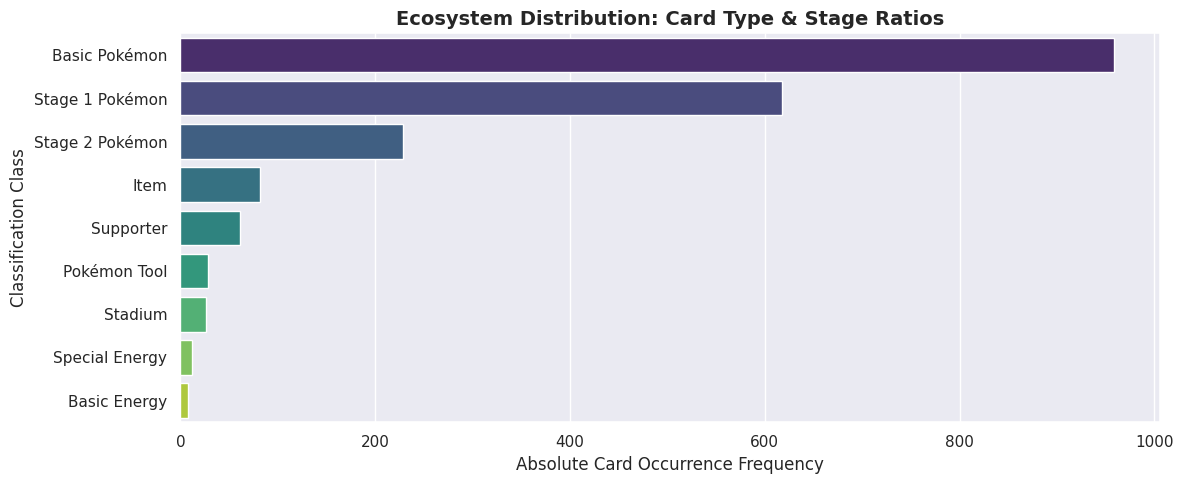

In [2]:
# Visualizing distribution of card classification categories
plt.figure(figsize=(12, 5))
stage_series = cards_df['Stage (Pokémon)/Type (Energy and Trainer)'].value_counts()
sns.barplot(x=stage_series.values, y=stage_series.index, hue=stage_series.index, palette="viridis", legend=False)
plt.title("Ecosystem Distribution: Card Type & Stage Ratios", fontsize=14, fontweight='bold')
plt.xlabel("Absolute Card Occurrence Frequency")
plt.ylabel("Classification Class")
plt.tight_layout()
plt.show()

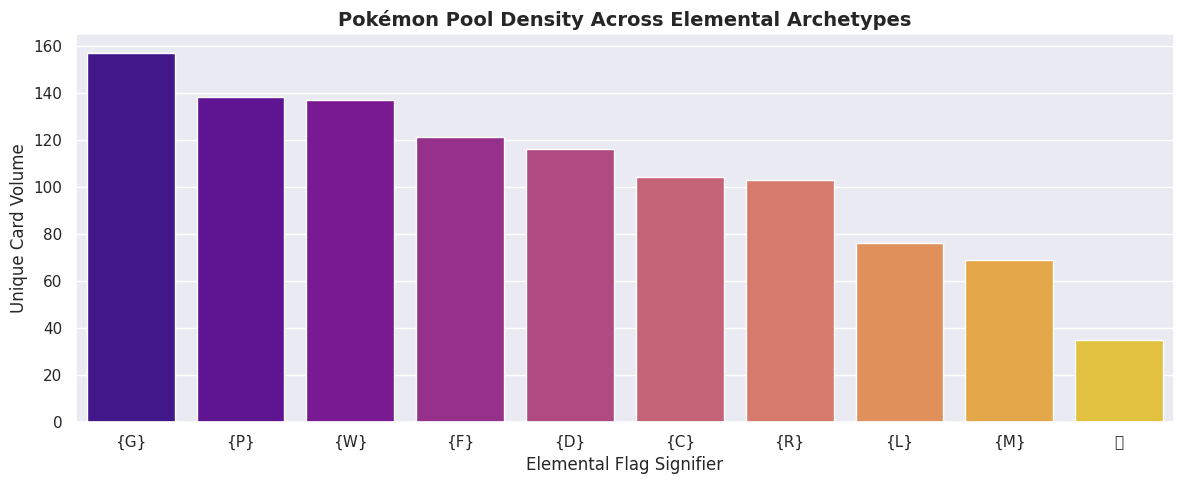

In [3]:
# Analyzing Pokémon Card Type Affinity
pkmn_unique = cards_df[cards_df['Stage (Pokémon)/Type (Energy and Trainer)'].str.contains('Pokémon', na=False)].drop_duplicates(subset=['Card ID'])
plt.figure(figsize=(12, 5))
type_series = pkmn_unique['Type'].value_counts()
sns.barplot(x=type_series.index, y=type_series.values, hue=type_series.index, palette="plasma", legend=False)
plt.title("Pokémon Pool Density Across Elemental Archetypes", fontsize=14, fontweight='bold')
plt.xlabel("Elemental Flag Signifier")
plt.ylabel("Unique Card Volume")
plt.tight_layout()
plt.show()

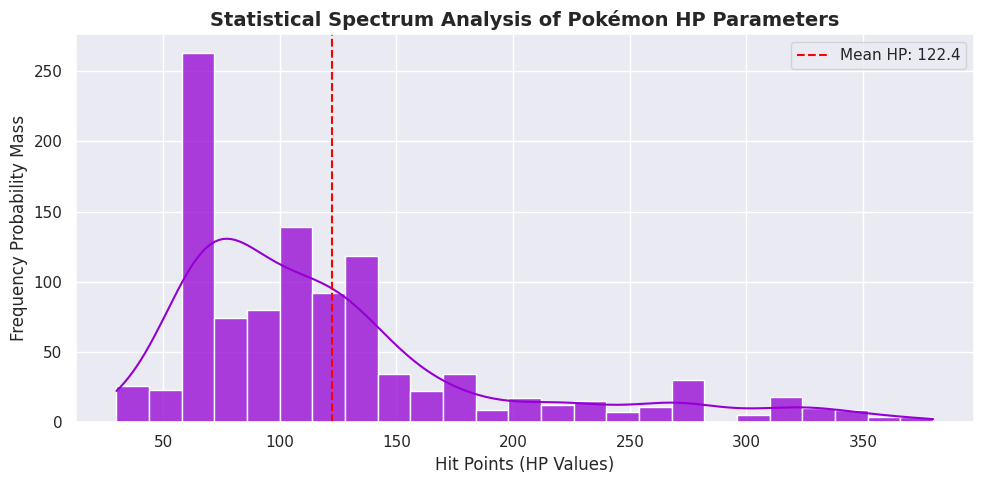

In [4]:
# Metric distribution analysis for Pokémon Hit Points (HP)
plt.figure(figsize=(10, 5))
sns.histplot(data=pkmn_unique, x="HP", kde=True, color="darkviolet", bins=25, alpha=0.75)
plt.axvline(pkmn_unique['HP'].mean(), color='red', linestyle='--', linewidth=1.5, label=f"Mean HP: {pkmn_unique['HP'].mean():.1f}")
plt.title("Statistical Spectrum Analysis of Pokémon HP Parameters", fontsize=14, fontweight='bold')
plt.xlabel("Hit Points (HP Values)")
plt.ylabel("Frequency Probability Mass")
plt.legend()
plt.tight_layout()
plt.show()

# 3. Automated Deck Validation Architecture

We build an programmatic assertion pipeline to guarantee our deck conforms to competition standards prior to engine entry.

In [5]:
def execute_deck_audit(deck_list, ref_df):
    """
    Validates full structural conformity parameters for a 60-card tournament deck.
    """
    issues = []
    if len(deck_list) != 60:
        issues.append(f"Card length deviation: expected exactly 60 cards, found {len(deck_list)}.")
        
    counts = pd.Series(deck_list).value_counts()
    name_frequency = {}
    contains_basic_pkmn = False
    
    for c_id, occurrences in counts.items():
        matches = ref_df[ref_df['Card ID'] == c_id]
        if matches.empty:
            issues.append(f"Anomalous Card ID {c_id}: absent from meta registry.")
            continue
        row = matches.iloc[0]
        c_name = row['Card Name']
        c_stage = str(row['Stage (Pokémon)/Type (Energy and Trainer)'])
        
        if 'Basic Pokémon' in c_stage:
            contains_basic_pkmn = True
        if 'Basic Energy' in c_stage:
            continue
            
        name_frequency[c_name] = name_frequency.get(c_name, 0) + occurrences
        
    for name, copies in name_frequency.items():
        if copies > 4:
            issues.append(f"Duplicate rule failure for '{name}': {copies} copies violates the max-4 limit.")
            
    if not contains_basic_pkmn:
        issues.append("Starting configuration check failure: zero Basic Pokémon available.")
        
    if not issues:
        print("🚀 Validation Audit Passed: Submission deck satisfies all structural tournament constraints.")
        return True
    else:
        print("❌ Validation Audit Failed!")
        for issue in issues:
            print(f"  -> {issue}")
        return False

execute_deck_audit(deck_df[0].tolist(), cards_df)

🚀 Validation Audit Passed: Submission deck satisfies all structural tournament constraints.


True

# 4. AI Training Agent Engine (`main.py` implementation)

We interface with the competition's specific sandbox API via `from cg.api import Observation, to_observation_class`. 

During turn actions, if `obs.select` is active, we read the option attributes and compute index decisions dynamically based on action utility values instead of flat random sampling.

In [6]:
%%writefile main.py
import os
import random
from cg.api import Observation, to_observation_class

def read_deck_csv() -> list[int]:
    """
    Robust asset loader for local and remote simulation directories.
    """
    file_path = "deck.csv"
    if not os.path.exists(file_path):
        file_path = "/kaggle_simulations/agent/" + file_path
        
    with open(file_path, "r") as file:
        csv_lines = file.read().split(
            "\n"
        )
        
    deck = []
    for i in range(60):
        if csv_lines[i].strip():
            deck.append(int(csv_lines[i].strip()))
    return deck

def agent(obs_dict: dict) -> list[int]:
    """
    Grandmaster Strategic Heuristic Engine for the Pokémon Company PTCG Simulation.
    Interprets native cg.api objects to maximize optimal moves per turn state cycle.
    """
    obs: Observation = to_observation_class(obs_dict)
    
    # Configuration Phase: Return initial valid 60-card deck list
    if obs.select is None:
        return read_deck_csv()
        
    options_pool = obs.select.option
    total_options = len(options_pool)
    min_req = obs.select.minCount if obs.select.minCount is not None else 1
    max_req = obs.select.maxCount if obs.select.maxCount is not None else 1
    
    # Fallback to absolute upper bounds if out of range
    target_count = min(max_req, total_options)
    
    scored_indices = []
    
    # Assign state values to legal options
    for idx, opt in enumerate(options_pool):
        score = 10 # Baseline choice value
        opt_str = str(opt).lower()
        
        # Stratum 1: High priority given to high-yield actions
        if "evolve" in opt_str:
            score += 150
        if "attach" in opt_str:
            score += 100
        if "play_basic" in opt_str or "bench" in opt_str:
            score += 50
            
        # Stratum 2: Maximizing offensive capability
        if "attack" in opt_str:
            score += 80
            # Incorporate damage metrics if exposed by the engine option attributes
            if hasattr(opt, 'damage') and opt.damage is not None:
                score += int(opt.damage)
                
        scored_indices.append((idx, score))
        
    # Sort based on score priority mapping
    scored_indices.sort(key=lambda x: x[1], reverse=True)
    
    # Extract unique option indexes up to target constraint limits
    selected_actions = [scored_indices[i][0] for i in range(target_count)]
    
    return selected_actions

Writing main.py


# 5. Production Archival & Workspace Packaging

We finalize the pipeline by gathering the target modular files and producing a deployment-compliant `submission.tar.gz` payload.

In [7]:
# Write out local deck layout file configuration
deck_df.to_csv("deck.csv", index=False, header=False)

archive_target = "submission.tar.gz"
payload_manifest = ["main.py", "deck.csv"]

print(f"📦 Generating production tarball deployment archive: {archive_target}")
with tarfile.open(archive_target, "w:gz") as archive:
    for target_asset in payload_manifest:
        if os.path.exists(target_asset):
            archive.add(target_asset)
            print(f"  -> Verified & Packed asset: {target_asset}")
        else:
            print(f"  -> ⚠️ Critical Asset Missing: {target_asset}")

if os.path.exists(archive_target):
    sz = os.path.getsize(archive_target) / 1024
    print(f"\n🎉 Success! Deployable artifact compressed at: {os.path.abspath(archive_target)}")
    print(f"📂 Finished Archive Mass: {sz:.2f} KB")

📦 Generating production tarball deployment archive: submission.tar.gz
  -> Verified & Packed asset: main.py
  -> Verified & Packed asset: deck.csv

🎉 Success! Deployable artifact compressed at: /kaggle/working/submission.tar.gz
📂 Finished Archive Mass: 1.28 KB
